### Query reqriting 

here we will improve our rag system by implementing a technique called Query Rewriting 

i.e instead of using a question written by the user, we re write it as a statemnt 
because the context of the prompt being question is not a good match for the embedded data.

or this may be query decomposition 
i.e if a users query has multiple intents such as lookling for multiple items and comparing them. 
here we would split the statements and run them as seperate querys.

Always choose as simple of a method as we can. 

In [ ]:
from pydantic import BaseModel

from langsmith import traceable, get_current_run_tree

import instructor

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send

from langchain_core.messages import SystemMessage
from IPython.display import Image, display

from typing import Literal, Dict, Any, Annotated, List
from operator import add

import random
import openai
import pandas as pd

from jinja2 import Template

from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

In [3]:
qdrant_client = QdrantClient(url="http://localhost:6333")

In [4]:
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    return response.data[0].embedding

In [5]:
def retrieve_data(query, qdrant_client, k=5, hybrid=True):

    query_embedding = get_embedding(query)

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                    text=query,
                    model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],

            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=k
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocess_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])


    return {
        "retrieved_context_ids":  retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    } 

/Users/chris/Desktop/ai-engineering-bootcamp-prerequisites/.venv/lib/python3.12/site-packages/qdrant_client/qdrant_remote.py:290: UserWarning: Failed to obtain server version. Unable to check client-server compatibility. Set check_compatibility=False to skip version check.
  show_warning(


In [6]:
query = "can you get a tablet?"

In [7]:
answer = retrieve_data(query, qdrant_client, k=10)

ResponseHandlingException: [Errno 61] Connection refused

In [ ]:
answer

{'retrieved_context_ids': ['B0BN58Z4YX',
  'B0BGHBL86V',
  'B0B157WDDJ',
  'B0C7DCS2KW',
  'B09RHF4L45',
  'B0B159KDFP',
  'B0BSD3QK7M',
  'B0BHVH4D37',
  'B0BCFYCXRH',
  'B0B58CPFWY'],
 'retrieved_context': ['ASWINN Tablet Tripod Stand, Gooseneck 65" Height Adjustable Tablet Stand Floor with 360° Rotating Tripod Mount Suitable for iPhone,Tablet,Kindle and All 4.5-12.9 Inch Tablet and Phone (Black)【Free Your Hands】: With this gooseneck arm tablet tripod stand, you can find a more comfortable way to use tablet & Phone in bed or sofa in winter. Release your hands while make your leisure time more enjoyable，the best Christmas gift or New Year gifts for wife,husband,elders,friend or colleague. 【Versatile Gooseneck Tablet Tripod Stand】This ergonomic gooseneck tablet holder suits most tablets and phones. you can easily get your desired angle to meet your needs at different angles and positions. Except for watching movies, you are also allowed to use your tablet for visual presentations, like

### Multi internt questions

In [ ]:
query = "can i get a watch for my kid, a tablet foe me and a laptop for my wife"

In [ ]:
answer = retrieve_data(query, qdrant_client, k=10)

In [ ]:
answer

{'retrieved_context_ids': ['B0B157WDDJ',
  'B0BN58Z4YX',
  'B0B159KDFP',
  'B0BGHBL86V',
  'B0BZM8YN4K',
  'B0B3R74TZC',
  'B0C7DCS2KW',
  'B0BHVF13PY',
  'B09W2BMG5N',
  'B0BT83RRJ2'],
 'retrieved_context': ["G-TiDE Kids Tablet, 7 inch Tablet for Kids, 32GB+2GB Kids Learning Tablet, 5MP Dual Camera HD, Parental Control App- KLAP, Toddler Tablet Case, WiFi Tablets Shoulder Straps, Pink🤗【Explore More Fun on Klap】G-TiDE Klap kids tablet is designed for learning and playing. This tablet for kids offers various creative contents such as brain training, painting, gaming, kids TV, etc. Learning while playing is better for kids to know the world. With a 32GB bigger storage, which can be extended to 128GB (micro SD card not included), this kids tablet is perfect for children aged 3-7 years old. You could get more educational apps from Google Play Store (GMS). 🤗【Kids-proof Case & Eye-protection Screen】G-TiDE's exclusive kids tablet case is made of impact-resistant EVA material. When your kid is

we narrow down on tablets but this is not enough to answer the above question 

only one retrieval pass
- so this is where we can run some query decomposition
- we will use instructor for this

In [ ]:
class QueryExpandResponse(BaseModel):
    statements: List[str] 

In [ ]:

def query_expansion_node(query) -> dict:

     prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

     template = Template(prompt_template)

     prompt = template.render(
          query=query
     )

     client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

     response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpandResponse
    )

     return {
        "queries": response.statements
    }


do not produce multiple statements with same intent -> 
dont want different statements that overlap eachother with same intention and different phrasing. 

See the examples too!

we can also write a question with a single intent into multiple statemnts 
- to improve the search 
- differnet statatemtns may pick up more relevant data
- i.e expanding seatch area

then we inject the users query as well

In [ ]:
answer = query_expansion_node(query)

In [ ]:
answer

{'queries': ['Kids watch', 'Tablet', 'Laptop for wife']}

{'queries': ['Kids watch', 'Tablet for personal use', 'Laptop for a spouse']}

in reality we would need to understand what the real user queries would be like before constructing the above prompt

now we will build a pipeline in langraph that will run this end to end

aggregating all the data retrieved by each serperate statament and aggreagte all into a final prompt

### LangGraph - Query Expansion (Sequential Execution)

In [ ]:
class State(BaseModel):
    expand_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
## add prevents overwiring of data in the list 
    initial_query: str = ""
    answer: str = ""

### Query Expansion / Rewriting Node

we are implementing two strategies at once with a single prompt 
- instead of a question we have statements - expanding
- instead of a single long question with multiple intents - we have decomposed it into multiple statements - decomposition

(usually we build as large a prompt as the llm can handle instead of chaining)

In [ ]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

we will make this traceable 
- as intiially will run sequentially 
- but will also run this in parallele with retrieval 
so we can see how much latency this will save with traceabilty

In [ ]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def query_expansion_node(state: State) -> dict:

    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpandResponse
    )

    return {
        "expanded_query": response.statements
    }

### Retriever node

In [ ]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retrieve_data(query, qdrant_client, k=5, hybrid=True):

    query_embedding = get_embedding(query)

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=k
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    ## will format the context in a single node to single md list (below)

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context

@traceable(
    name="retriever_node",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    qdrant_client = QdrantClient(url="http://localhost:6333")

    retrieved_context = []

    for query in state.expanded_query:
        retrieved_context.append(retrieve_data(query, qdrant_client, k=5))

    return {
        "retrieved_context": retrieved_context
    }

### Aggregator Node

will aggregate all of the context built by the retrieval node

In [ ]:
class AggregatorResponse(BaseModel):
    answer: str

In [ ]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def aggregator_node(state: State) -> dict:

## Joing all the strings in the list with retrieved context key
    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

### Instructions

- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

### Context

{{ preprocessed_context }}

### Question

{{ question }}
"""
## Build template and render the prompt
    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=AggregatorResponse
    )

    return {
        "answer": response.answer
    }

### Build the graph

All nodes connected sequentially here

In [ ]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("query_expansion_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

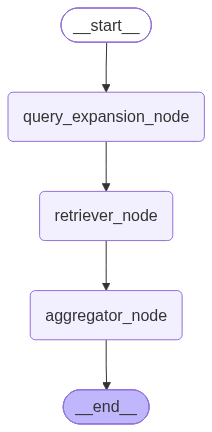

In [ ]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
query = "can i get a watch for my kid, a tablet foe me and a laptop for my wife"

In [ ]:
initial_state = {
    "initial_query": query
}

NameError: name 'query' is not defined

In [ ]:
result = graph.invoke(initial_state)

In [ ]:
result

In [ ]:
print(result["answer"])

print(result["answer"]) 

### Query Expansion (Parallel Execution)
Running the decomposed query statements in paralelle

the global state may be changing so we add
query and k 
to the local state

In [ ]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""
    query: str = ""
    k: int = 10

### Query Expansion / Rewriting Node (Parallele)

In [ ]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [ ]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def query_expansion_node(state: State) -> dict:

    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpandResponse
    )

    return {
        "expanded_query": response.statements
    }

conditional edge compute below 
this is for the parallele compute for each of the querys created by previous node

we append the send object with the local state 
need to isolate the states of the nodes running in paralelle
to avoid distributed conflicts

we will kick off a dynamic number of parallele nodes below

In [ ]:
def query_expand_conditional_edges(state: State) -> dict:

    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": state.k
                }
            )
        )

    return send_messages

### Retriever node (Parallele)

In [8]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    hybrid = True
    ## Why is hybrid now true? (it should be)

    qdrant_client = QdrantClient(url="http://localhost:6333")

    query_embedding = get_embedding(state["query"])

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=state["k"]
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=state["k"]
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return {
        "retrieved_context": [formatted_context]
    }

NameError: name 'State' is not defined

### Aggregator Node (paralelle but unchanged)

In [ ]:
class AggregatorResponse(BaseModel):
    answer: str

In [ ]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

### Instructions

- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

### Context

{{ preprocessed_context }}

### Question

{{ question }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=AggregatorResponse
    )

    return {
        "answer": response.answer
    }

In [9]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

## add contitional egdees for parallele compute to graph
workflow.add_conditional_edges(
    "query_expansion_node",
    query_expand_conditional_edges
)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

NameError: name 'State' is not defined

the output image shows that the retiever and aggregator nodes are sperate 
this is due to the parallele nodes inbetween 
as langgraph does not know how many parallele nodes witll be run at this stage

In [ ]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"

In [ ]:
initial_state = {
    "initial_query": query
}

In [ ]:
result = graph.invoke(initial_state)

In [ ]:
result

In [ ]:
print(result["answer"])

we will now see the parallele node run viisble in langsmith